# CSDA summary of multi-spec imagery

Paul Montesano, PhD  
August 2025

In [1]:
install.packages("DT")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [2]:
install.packages("kableExtra")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [3]:
library(tidyverse)
library(lubridate)
library(RColorBrewer)
library(googlesheets4)
library(DT)
library(kableExtra)
library(ggrepel)
library(IRdisplay)
library(knitr)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘kableExtra’


The following object is masked from ‘package:dplyr’:

    group_rows




In [4]:
# Authenticate
gs4_deauth()

In [5]:
# # sheet_id = 'Specs'
# # spreadsheet_id = '13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k'
# # url = f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?format=csv&gid={sheet_id}'
# url = '/projects/my-private-bucket/databank/csda/NASA CSDA Multi-Spectral Sensor Platform Metadata - Vendor Specs.csv'

In [6]:
#f = head(read.csv(url, skip = 2),10)

In [7]:
sheet_id = '13MrpqFtAOqQY9WdW9lHNsqjCbG-e3VQkEDbHOGIKa6k'
df = read_sheet(sheet_id, sheet = 'Vendor Specs', skip = 2) %>% 
    as.data.frame() %>%
    mutate(Constellation = ifelse(is.na(`Constellation/Platform`), ' ', `Constellation/Platform`)) %>%
    mutate(`Branded Name` = ifelse(is.na(`Branded Name`), ' ', `Branded Name`)) 

✔ Reading from CSDA Prototype Vendor Specifications & Evaluation DB.

✔ Range ''Vendor Specs'!3:10000000'.

New names:
• `site` -> `site...21`
• `Image Product Type` -> `Image Product Type...23`
• `# of individual satellites evaluated` -> `# of individual satellites
  evaluated...24`
• `# of images evaluated` -> `# of images evaluated...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `site` -> `site...34`
• `Image Product Type` -> `Image Product Type...36`
• `# of individual satellites evaluated` -> `# of individual satellites
  evaluated...37`
• `# of images evaluated` -> `# of images evaluated...38`


In [8]:
names(df)[c(1:10, 45:53)]

[1] "Sensor/Generation"                  "Constellation/Platform"            
 [3] "Launch Date"                        "End Date"                          
 [5] "Branded Name"                       "Reference"                         
 [7] "Affiliation"                        "Sector"                            
 [9] "Mission Status"                     "Satellite Size Class"              
[11] "FWHM nir mean"                      "FWHM nir std"                      
[13] "MTF"                                "CE90 (APA) [m]"                    
[15] "CE90 (APA) [n pixels]"              "CE90 demean (precision) [m]"       
[17] "CE90 demean (precision) [n pixels]" "BBR [m]"                           
[19] "overlapped area [%]"

In [9]:
# Create the summarized table

summary_table <- df %>%
  # Combine Sensor/Generation and Constellation
  mutate(`Constellation/Sensor` = paste(`Constellation`,`Sensor/Generation`, sep = " - ")) %>%
  # Select the columns we want to summarize
  select(`Constellation/Sensor`, `Affiliation`, `Sector`,
         `Revisit Time (days)`, 
         `Swath Width (km)`, 
         `Scanner Type`,
         `MS GSD Nadir (m)`,
        # `Collection Strategy`, 
         #`Mission Status`, 
         `n satellites`, `Geolocation Accuracy (CE90)`,`Agility (off-nadir)`,`Stereo Capability`,`Radiometric Resolution`,
         #`Calibration Accuracy`,
         `Sharpness (MTF)`,
         `Total Bands (MS)`, `Total Bands`) %>%
  # Remove any duplicate rows if needed
  distinct() %>%
  mutate(across(c(`MS GSD Nadir (m)`,`Total Bands (MS)`), as.character)) %>%
  mutate(across(c(`MS GSD Nadir (m)`,`Total Bands (MS)`), ~replace_na(., ""))) %>%
  mutate(across(where(is.character), ~replace_na(., " ")))# %>%
  #mutate(across(where(is.numeric), ~replace_na(., -Inf)))


# To get it as markdown, you can use knitr::kable()
library(knitr)
markdown_table <- kable(summary_table, format = "markdown")

# Design the custom summary table
## `You'll want to change this every time you run this notebook`

In [10]:
# Define your custom order (replace with your desired order)
custom_order_affiliation_list <- c('US Agency','ESA','Airbus','Satellogic','BlackSky','Planet Labs')

# Define the platforms that you dont want to see (easier than specifying what you DO want to see?)
#custom_remove_platform_list <- c('SkySat','Pelican') # TODO --- work this in below
custom_remove_platform_list <- c('Pelican')
custom_remove_platform_regex <- paste0(custom_remove_platform_list, collapse = "|")

In [11]:
summary_table_subset = summary_table %>% 
                filter(`Affiliation` %in% custom_order_affiliation_list) %>%
                filter(!grepl(custom_remove_platform_regex, `Constellation/Sensor`)) %>% 
                filter(Affiliation == 'Planet Labs') %>% droplevels()
dim(summary_table_subset)

[1]  8 15

In [12]:

# Pivot the data frame
pivoted_summary_table <- summary_table_subset %>%
  mutate(across(c(`Constellation/Sensor`, `Affiliation`, `Sector`,
         `Revisit Time (days)`, 
         `Swath Width (km)`, 
         `Scanner Type`,
         `MS GSD Nadir (m)`,
         `n satellites`, `Geolocation Accuracy (CE90)`,`Agility (off-nadir)`,`Stereo Capability`,`Radiometric Resolution`,
                  #`Calibration Accuracy`,
                  `Sharpness (MTF)`,
         `Total Bands (MS)`, `Total Bands`), 
                as.character)) %>%
  pivot_longer(
    cols = c( 
       `Sector`,
        `Affiliation`,
         `Revisit Time (days)`, 
         `Swath Width (km)`, 
         `Scanner Type`,
         `MS GSD Nadir (m)`,
         `n satellites`, `Geolocation Accuracy (CE90)`,`Agility (off-nadir)`,`Stereo Capability`,`Radiometric Resolution`,
        #`Calibration Accuracy`,
        `Sharpness (MTF)`,
         `Total Bands (MS)`, `Total Bands`),
    names_to = "Vendor Specifications",
    values_to = "temp_value"
  ) %>%
  pivot_wider(
    names_from = `Constellation/Sensor`,
    values_from = temp_value
  )

# FIXED: Create sensor order based on parent company order
# Get the parent company for each sensor
parent_company_mapping <- pivoted_summary_table %>%
  filter(`Vendor Specifications` == "Affiliation") %>%
  select(-`Vendor Specifications`) %>%
  pivot_longer(everything(), names_to = "sensor", values_to = "company")

# Order sensors by parent company according to custom_order_affiliation_list
ordered_sensors <- parent_company_mapping %>%
  mutate(company = factor(company, levels = custom_order_affiliation_list)) %>%
  arrange(company) %>%
  pull(sensor)

# Reorder columns
pivoted_summary_table <- pivoted_summary_table %>%
  select(`Vendor Specifications`, all_of(ordered_sensors))

# Define color mapping for parent companies
company_colors <- c(
  "US Agency" = "#e8eaed",
  "ESA" = "#ffc8aa", 
  "Airbus" = "#e6cff2",
  "BlackSky" = "#3d3d3d",
  "Satellogic" = "#ffe5a0"
)

# Get parent company values for each column (excluding 'Vendor Specifications' column)
parent_companies <- pivoted_summary_table %>%
  filter(`Vendor Specifications` == "Affiliation") %>%
  select(-`Vendor Specifications`) %>%
  unlist()
    
pivoted_summary_table_html = pivoted_summary_table %>%
  kable(format = "html") %>%
  kable_styling() %>%
  row_spec(0, background = "darkgray")

# # Color each column based on parent company
# for(i in 1:length(parent_companies)) {
#   company <- parent_companies[i]
#   if(company %in% names(company_colors)) {
#     pivoted_summary_table_html <- pivoted_summary_table_html %>%
#       column_spec(i + 1, background = company_colors[company])  # i+1 because first col is 'Specs'
#   }
# }

# pivoted_summary_table_html = pivoted_summary_table_html %>%
#   column_spec(c(2,3,4), background = "#2b8cbe")

display_html(as.character(pivoted_summary_table_html))

Vendor Specifications,RapidEye - 1 - 5,SkySat - A/B,SkySat - C1,SkySat - C2,PlanetScope - Dove-Classic,PlanetScope - Dove-R,Tanager - Gen 1,PlanetScope - SuperDove
Sector,Commercial,Commercial,Commercial,Commercial,Commercial,Commercial,Commercial,Commercial
Affiliation,Planet Labs,Planet Labs,Planet Labs,Planet Labs,Planet Labs,Planet Labs,Planet Labs,Planet Labs
Revisit Time (days),1,1,1,1,1,1,4.5,1
Swath Width (km),77,8,5.9,5.5,24,24,18,24
Scanner Type,Pushbroom,Frame/Video,Pushframe,Pushframe,Frame,Frame,Pushbroom,Frame
MS GSD Nadir (m),5,,,,3.7,3,30,3
n satellites,5,2,13,6,100,50,NA,130
Geolocation Accuracy (CE90),<10m,<5m,,,<50m,<10m,,<7m
Agility (off-nadir),±25°,±35°,,,Limited,Limited,,Limited
Stereo Capability,Limited,Yes,,,No,Limited,,Limited


In [13]:
parent_companies

RapidEye - 1 - 5               SkySat - A/B 
             "Planet Labs"              "Planet Labs" 
               SkySat - C1                SkySat - C2 
             "Planet Labs"              "Planet Labs" 
PlanetScope - Dove-Classic       PlanetScope - Dove-R 
             "Planet Labs"              "Planet Labs" 
           Tanager - Gen 1    PlanetScope - SuperDove 
             "Planet Labs"              "Planet Labs"

In [14]:
datatable(summary_table)

HTML widgets cannot be represented in plain text (need html)

In [15]:
levels(factor(df$`Affiliation`))

[1] "Airbus"      "BlackSky"    "ESA"         "EarthDaily"  "HydroSat"   
 [6] "JAXA"        "Maxar"       "Planet Labs" "SatVu"       "Satellogic" 
[11] "US Agency"

## Tables

#### Satellite size classes

| Size Class | Mass Range (kg) | Typical Examples |
|------------|----------------|------------------|
| **Large** | > 1,000 | Geostationary communication satellites, large Earth observation satellites |
| **Medium** | 500 - 1,000 | Regional communication satellites, some scientific missions |
| **Mini** | 100 - 500 | Small Earth observation satellites, technology demonstrators |
| **Micro** | 10 - 100 | University research satellites, constellation satellites |
| **Nano** | 1 - 10 | CubeSats (1U-6U typically), educational satellites |

**Additional Notes:**
- **Pico** satellites (0.1 - 1 kg) and **Femto** satellites (< 0.1 kg) are sometimes used for even smaller classifications
- CubeSats are a popular standard within the nano class, with 1U ≈ 1.33 kg, 3U ≈ 4 kg, 6U ≈ 8 kg
- These classifications can vary slightly between different organizations and applications
- The boundaries between classes are not universally standardized and may differ in some contexts

## Plots

In [16]:
library(RColorBrewer)

create_advanced_combined_palette <- function(df, column, 
                                           palette_config = list(
                                             list(palette = "Set1", weight = 0.5),
                                             list(palette = "Set2", weight = 0.5)
                                           ),
                                           method = "weighted",
                                           override_colors = NULL) {
  # Extract the column as factor
  factor_col <- as.factor(df[[column]])
  unique_levels <- levels(factor_col)
  n_levels <- length(unique_levels)
  
  # First handle automatic palette generation
  if (method == "weighted") {
    # Calculate how many colors to take from each palette based on weights
    weights <- sapply(palette_config, function(x) x$weight)
    weights <- weights / sum(weights)  # Normalize weights
    
    n_colors <- round(n_levels * weights)
    n_colors[length(n_colors)] <- n_levels - sum(n_colors[-length(n_colors)])  # Adjust last to sum to total
    
    all_colors <- character(0)
    
    for (i in seq_along(palette_config)) {
      if (n_colors[i] > 0) {
        palette_name <- palette_config[[i]]$palette
        max_colors <- brewer.pal.info[palette_name, "maxcolors"]
        
        if (n_colors[i] <= max_colors) {
          pal_colors <- brewer.pal(max(3, n_colors[i]), palette_name)[1:n_colors[i]]
        } else {
          base_colors <- brewer.pal(max_colors, palette_name)
          pal_colors <- colorRampPalette(base_colors)(n_colors[i])
        }
        
        all_colors <- c(all_colors, pal_colors)
      }
    }
    
    colors <- all_colors[1:n_levels]
  } else {
    # Default to a single palette if method not recognized
    if (n_levels <= 9) {
      colors <- brewer.pal(max(3, n_levels), palette_config[[1]]$palette)[1:n_levels]
    } else {
      max_colors <- brewer.pal.info[palette_config[[1]]$palette, "maxcolors"]
      base_colors <- brewer.pal(max_colors, palette_config[[1]]$palette)
      colors <- colorRampPalette(base_colors)(n_levels)
    }
  }
  
  # Create initial named vector
  color_dict <- setNames(colors, unique_levels)
  
  # Apply override colors if provided
  if (!is.null(override_colors)) {
    # Check which override levels exist in our factor levels
    valid_overrides <- names(override_colors)[names(override_colors) %in% unique_levels]
    
    # Apply valid overrides
    for (level in valid_overrides) {
      color_dict[level] <- override_colors[level]
    }
    
    # Optionally warn about invalid overrides
    invalid_overrides <- names(override_colors)[!names(override_colors) %in% unique_levels]
    if (length(invalid_overrides) > 0) {
      warning(paste("The following override levels were not found in the data:", 
                    paste(invalid_overrides, collapse=", ")))
    }
  }
  
  return(color_dict)
}

# Example with sequential method too
create_combined_color_dict <- function(df, column, palette1 = "Set1", palette2 = "Set2", 
                                      split_point = NULL, method = "sequential",
                                      override_colors = NULL) {
  # Extract the column as factor
  factor_col <- as.factor(df[[column]])
  unique_levels <- levels(factor_col)
  n_levels <- length(unique_levels)
  
  # Determine split point if not provided
  if (is.null(split_point)) {
    split_point <- ceiling(n_levels / 2)
  }
  
  # Ensure split_point is within valid range
  split_point <- max(1, min(split_point, n_levels - 1))
  
  # Method 1: Sequential - first palette for first part, second for second part
  if (method == "sequential") {
    # Colors from first palette
    n1 <- split_point
    if (n1 <= 3) {
      colors1 <- brewer.pal(max(3, n1), palette1)[1:n1]
    } else if (n1 <= brewer.pal.info[palette1, "maxcolors"]) {
      colors1 <- brewer.pal(n1, palette1)
    } else {
      colors1 <- colorRampPalette(brewer.pal(brewer.pal.info[palette1, "maxcolors"], palette1))(n1)
    }
    
    # Colors from second palette
    n2 <- n_levels - split_point
    if (n2 > 0) {
      if (n2 <= 3) {
        colors2 <- brewer.pal(max(3, n2), palette2)[1:n2]
      } else if (n2 <= brewer.pal.info[palette2, "maxcolors"]) {
        colors2 <- brewer.pal(n2, palette2)
      } else {
        colors2 <- colorRampPalette(brewer.pal(brewer.pal.info[palette2, "maxcolors"], palette2))(n2)
      }
      colors <- c(colors1, colors2)
    } else {
      colors <- colors1
    }
  }
  
  # Other methods would go here (interleaved, blended, etc.)
  # ...
  
  # Create initial color dictionary
  color_dict <- setNames(colors[1:n_levels], unique_levels)
  
  # Apply override colors if provided
  if (!is.null(override_colors)) {
    # Check which override levels exist in our factor levels
    valid_overrides <- names(override_colors)[names(override_colors) %in% unique_levels]
    
    # Apply valid overrides
    for (level in valid_overrides) {
      color_dict[level] <- override_colors[level]
    }
    
    # Optionally warn about invalid overrides
    invalid_overrides <- names(override_colors)[!names(override_colors) %in% unique_levels]
    if (length(invalid_overrides) > 0) {
      warning(paste("The following override levels were not found in the data:", 
                    paste(invalid_overrides, collapse=", ")))
    }
  }
  
  return(color_dict)
}
                      create_color_dict <- function(df, column, palette = "Set1") {
  # Extract the column as factor
  factor_col <- as.factor(df[[column]])
  unique_levels <- levels(factor_col)
  n_levels <- length(unique_levels)
  
  # Handle case where we need more colors than palette provides
  if (n_levels <= 3) {
    colors <- brewer.pal(max(3, n_levels), palette)[1:n_levels]
  } else if (n_levels <= brewer.pal.info[palette, "maxcolors"]) {
    colors <- brewer.pal(n_levels, palette)
  } else {
    # Use colorRampPalette for more colors
    colors <- colorRampPalette(brewer.pal(brewer.pal.info[palette, "maxcolors"], palette))(n_levels)
  }
  
  # Create named vector (dictionary)
  color_dict <- setNames(colors, unique_levels)
  
  return(color_dict)
}

In [17]:
CAPTION_TEXT = 'Montesano, Nickeson NASA GSFC'
MAIN_TITLE = 'Summary of commercial multi-spectral satellite specifications'

In [18]:
# Usage
color_dict <- create_color_dict(df, "Affiliation", "Set1")
color_dict <- create_advanced_combined_palette(df, "Affiliation")
# Example 1: Using the weighted method with overrides
color_dict <- create_advanced_combined_palette(
  df, "Affiliation", 
  palette_config = list(
    list(palette = "Set1", weight = 0.5),
    list(palette = "Dark2", weight = 0.5)
  ),
  override_colors = c('BlackSky' = 'black', 'US Agency' = 'blue')
)

Warning message in geom_text_repel(data = df_unique_labels, aes(label = paste0(`Constellation/Sensor`)), :
“Ignoring unknown parameters: `fill`”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”


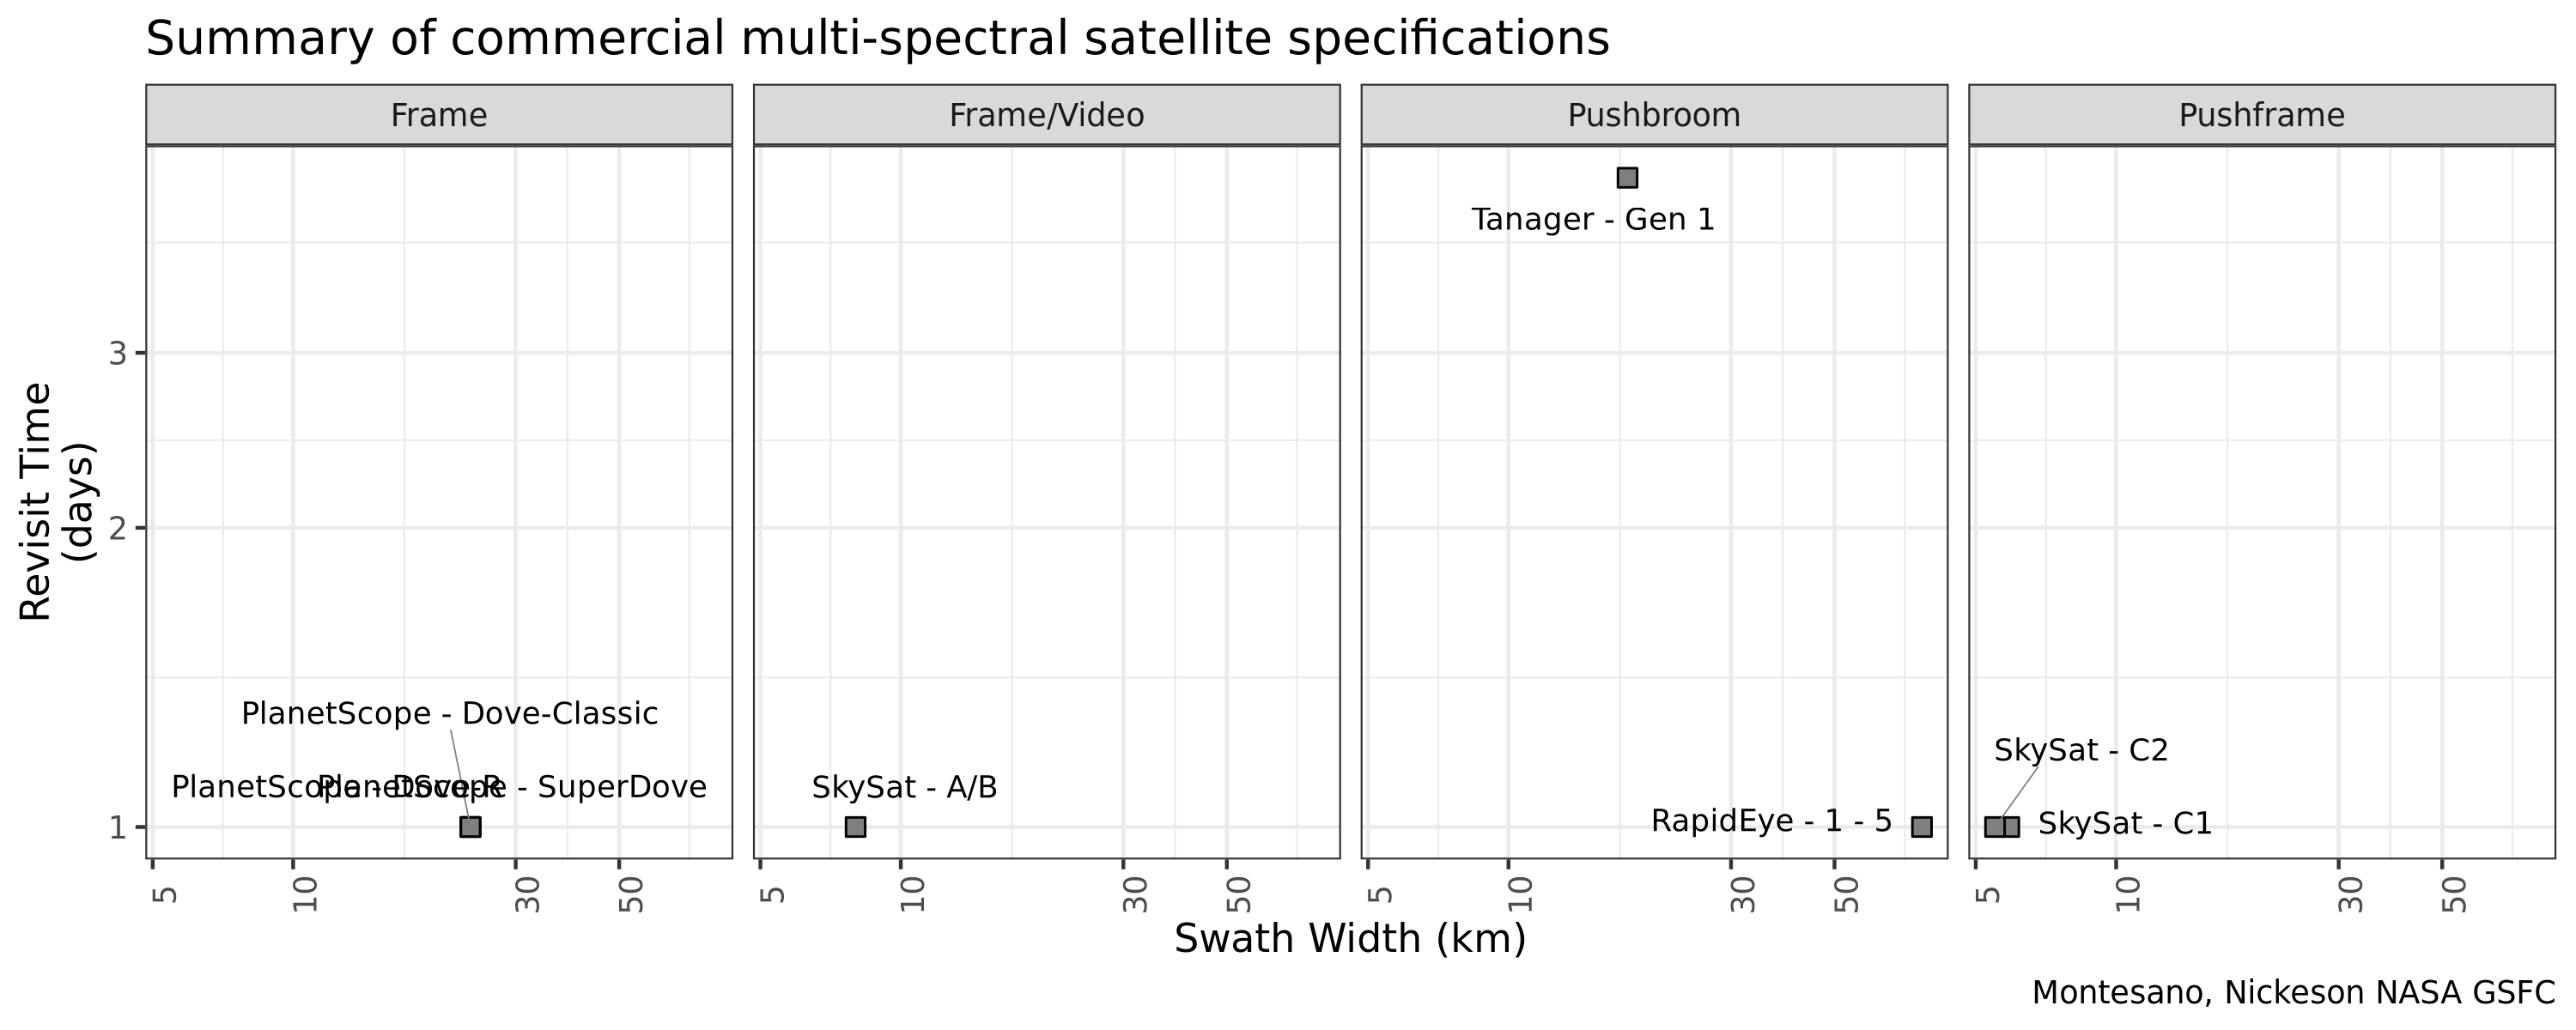

In [19]:
options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 300)

# Create a dataset with one label per unique position
df_unique_labels <- summary_table_subset %>%
  group_by(`Constellation/Sensor`,`Swath Width (km)`, `MS GSD Nadir (m)`) %>%
  slice(1) %>%  # Take first row from each group
  ungroup()

ggplot(summary_table_subset , aes(x=`Swath Width (km)`, y=as.numeric(`Revisit Time (days)`), fill=`Affiliation`)) +
    geom_point(size=2.5, shape=22, color='black',alpha=1) +    
    geom_text_repel(
        data = df_unique_labels,  # Use the filtered dataset for labels
        aes(label=paste0(`Constellation/Sensor`)), 
        size=3, color='black',
        show.legend = FALSE,
        box.padding = 0.5,
        point.padding = 0.03,
        segment.color = 'grey50',
        segment.size = 0.2,
        max.overlaps = Inf,
        seed = 42, fill='NA', alpha=1
    ) +
    scale_fill_manual(values=company_colors) + scale_color_manual(values=company_colors) +
    scale_x_log10() +
    scale_y_log10() +
    theme_bw() + 
    theme(axis.text.x = element_text(angle=90)) +
    facet_wrap(~`Scanner Type`, nrow=1) + labs(y = 'Revisit Time\n(days)'
                                           , caption=CAPTION_TEXT
                                          , title=MAIN_TITLE)
#facet_grid(`Satellite.Type`~`Scanner.Type`)

Warning message in geom_text_repel(data = df_unique_labels, aes(label = paste0(`Constellation/Sensor`)), :
“Ignoring unknown parameters: `fill`”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's colour values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“No shared levels found between `names(values)` of the manual scale and the
data's fill values.”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 3 rows containing missing values or values outside the scale range
(`geom_text_repel()`).”


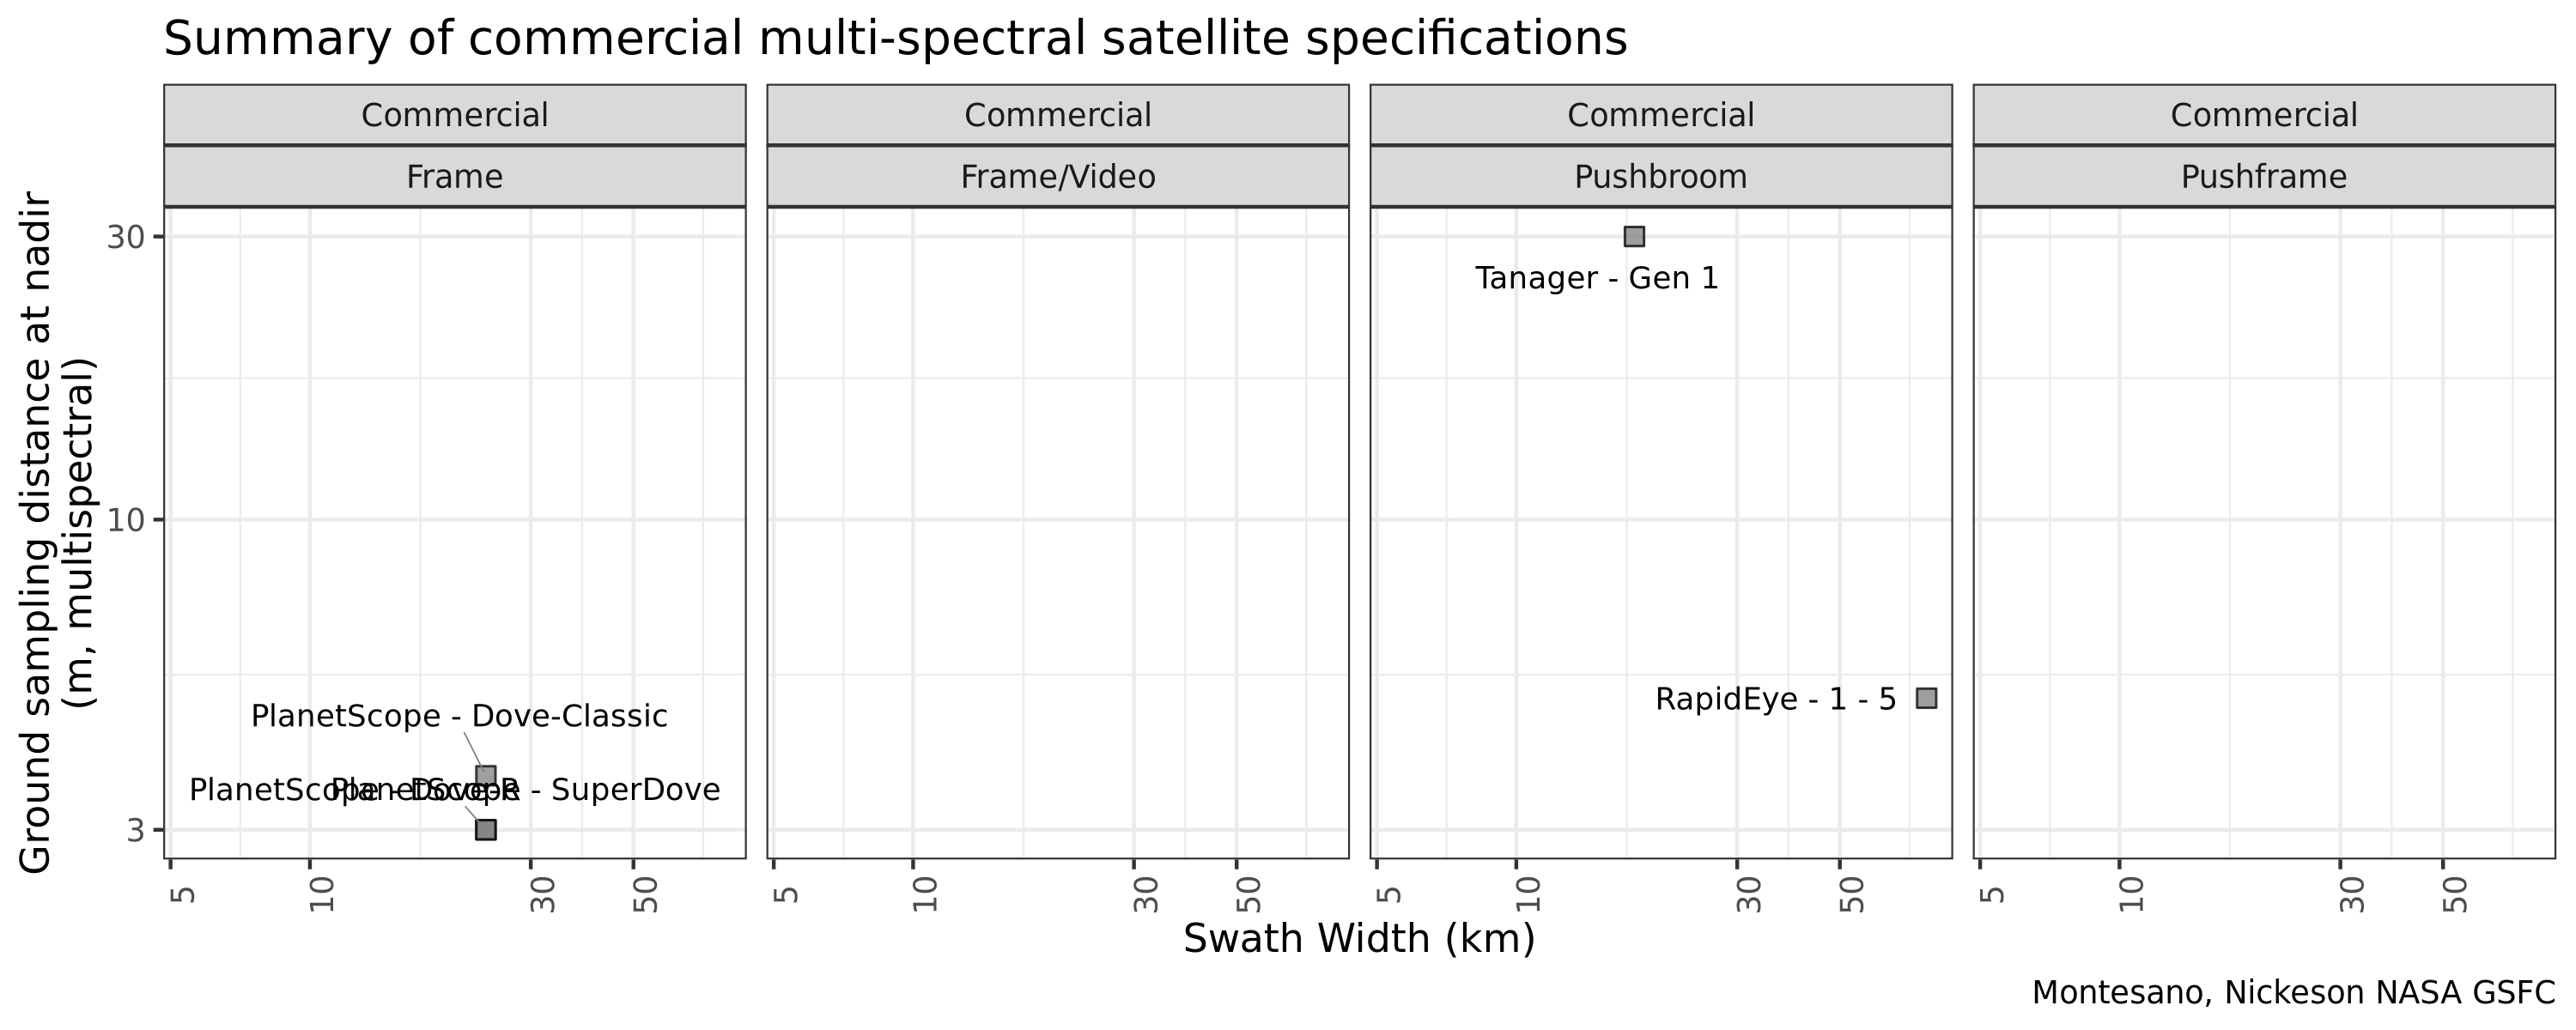

In [21]:
options(repr.plot.width = 10, repr.plot.height = 4, repr.plot.res = 300)

# Create a dataset with one label per unique position
df_unique_labels <- summary_table_subset %>%
  group_by(`Constellation/Sensor`, `Swath Width (km)`, `MS GSD Nadir (m)`) %>%
  slice(1) %>%  # Take first row from each group
  ungroup()

ggplot(summary_table_subset, aes(x=`Swath Width (km)`, y=as.numeric(`MS GSD Nadir (m)`), fill=`Affiliation`)) +
    geom_point(size=2.5, shape=22, color='black',alpha=0.75) +    
    geom_text_repel(
        data = df_unique_labels,  # Use the filtered dataset for labels
        aes(label=paste0(`Constellation/Sensor`)), 
        size=3, color='black',
        show.legend = FALSE,
        box.padding = 0.5,
        point.padding = 0.03,
        segment.color = 'grey50',
        segment.size = 0.2,
        max.overlaps = Inf,
        seed = 42, fill='NA', alpha=1
    ) +
    scale_fill_manual(values=company_colors) + scale_color_manual(values=company_colors) +
    scale_x_log10() +
    scale_y_log10() +
    theme_bw() + 
    theme(axis.text.x = element_text(angle=90)) +
    facet_wrap(Sector~`Scanner Type`, nrow=1) + labs(y = 'Ground sampling distance at nadir\n(m, multispectral)'
                                           , caption=CAPTION_TEXT
                                          , title=MAIN_TITLE)

## Spectral Metadata

In [38]:
min_cols_data <- df %>% select(contains("min")) %>% select(contains("nm"))
cols_min = names(min_cols_data)
cols_min

[1] "Pan Min (nm)"        "Coastal Min (nm)"    "Blue Min (nm)"      
 [4] "Blue2 Min (nm)"      "Green1 Min (nm)"     "Green2 Min (nm)"    
 [7] "Yellow Min (nm)"     "Red Min (nm)"        "RedEdge Min (nm)"   
[10] "RedEdge1 Min (nm)"   "RedEdge2 Min (nm)"   "NIR Min (nm)"       
[13] "NIR2 Min (nm)"       "NIR WV Min (nm)"     "SWIRCirrus Min (nm)"
[16] "SWIR1 Min (nm)"      "SWIR2 Min (nm)"

In [39]:
max_cols_data <- df %>% select(contains("max")) %>% select(contains("nm"))
cols_max = names(max_cols_data)
cols_max

[1] "Pan Max (nm)"        "Coastal Max (nm)"    "Blue Max (nm)"      
 [4] "Blue2 Max (nm)"      "Green1 Max (nm)"     "Green2 Max (nm)"    
 [7] "Yellow Max (nm)"     "Red Max (nm)"        "RedEdge Max (nm)"   
[10] "RedEdge1 Max (nm)"   "RedEdge2 Max (nm)"   "NIR Max (nm)"       
[13] "NIR2 Max (nm)"       "NIR WV Max (nm)"     "SWIRCirrus Max (nm)"
[16] "SWIR1 Max (nm)"      "SWIR2 Max (nm)"

In [40]:
(cols_min)

[1] "Pan Min (nm)"        "Coastal Min (nm)"    "Blue Min (nm)"      
 [4] "Blue2 Min (nm)"      "Green1 Min (nm)"     "Green2 Min (nm)"    
 [7] "Yellow Min (nm)"     "Red Min (nm)"        "RedEdge Min (nm)"   
[10] "RedEdge1 Min (nm)"   "RedEdge2 Min (nm)"   "NIR Min (nm)"       
[13] "NIR2 Min (nm)"       "NIR WV Min (nm)"     "SWIRCirrus Min (nm)"
[16] "SWIR1 Min (nm)"      "SWIR2 Min (nm)"

In [41]:
names(df)

[1] "Sensor/Generation"                        
  [2] "Constellation/Platform"                   
  [3] "Launch Date"                              
  [4] "End Date"                                 
  [5] "Branded Name"                             
  [6] "Reference"                                
  [7] "Affiliation"                              
  [8] "Sector"                                   
  [9] "Mission Status"                           
 [10] "Satellite Size Class"                     
 [11] "assessment status"                        
 [12] "site...12"                                
 [13] "Radiometric Reference Sensor"             
 [14] "Image Product Type...14"                  
 [15] "# of individual satellites evaluated...15"
 [16] "# of images evaluated...16"               
 [17] "...17"                                    
 [18] "...18"                                    
 [19] "...19"                                    
 [20] "SNR blue"                                 
 [21] "SNR green"                                
 [22] "SNR red"                                  
 [23] "SNR nir"                                  
 [24] "no quantitative measure defined when n<10"
 [25] "site...25"                                
 [26] "Geometric Reference Sensor"               
 [27] "Image Product Type...27"                  
 [28] "# of individual satellites evaluated...28"
 [29] "# of images evaluated...29"               
 [30] "FWHM blue mean"                           
 [31] "FWHM blue std"                            
 [32] "FWHM green mean"                          
 [33] "FWHM green std"                           
 [34] "FWHM red mean"                            
 [35] "FWHM red std"                             
 [36] "FWHM nir mean"                            
 [37] "FWHM nir std"                             
 [38] "MTF"                                      
 [39] "CE90 (APA) [m]"                           
 [40] "CE90 (APA) [n pixels]"                    
 [41] "CE90 demean (precision) [m]"              
 [42] "CE90 demean (precision) [n pixels]"       
 [43] "BBR [m]"                                  
 [44] "overlapped area [%]"                      
 [45] "Weight Range (kg)"                        
 [46] "Orbit Type"                               
 [47] "Orbit Altitude (km)"                      
 [48] "Orbit Period (min)"                       
 [49] "Revisit Time (days)"                      
 [50] "Swath Width (km)"                         
 [51] "Scanner Type"                             
 [52] "Acquisition Strategy"                     
 [53] "n satellites"                             
 [54] "Pan GSD Nadir (m)"                        
 [55] "MS GSD Nadir (m)"                         
 [56] "SWIR GSD Nadir (m)"                       
 [57] "TIR GSD Nadir (m)"                        
 [58] "Pan GSD Off-Nadir Min (m)"                
 [59] "Pan GSD Off-Nadir Max (m)"                
 [60] "MS GSD Off-Nadir Min (m)"                 
 [61] "MS GSD Off-Nadir Max (m)"                 
 [62] "Geolocation Accuracy (CE90)"              
 [63] "Agility (off-nadir)"                      
 [64] "Stereo Capability"                        
 [65] "DEM Generation"                           
 [66] "Bit Depth"                                
 [67] "Radiometric Resolution"                   
 [68] "SNR (Pan/MS)"                             
 [69] "Dynamic Range"                            
 [70] "Calibration Accuracy"                     
 [71] "Sharpness (MTF)"                          
 [72] "Pan Min (nm)"                             
 [73] "Pan Max (nm)"                             
 [74] "Coastal Min (nm)"                         
 [75] "Coastal Max (nm)"                         
 [76] "Blue Min (nm)"                            
 [77] "Blue Max (nm)"                            
 [78] "Blue2 Min (nm)"                           
 [79] "Blue2 Max (nm)"                           
 [80] "Green1 Min (nm)"                          
 [

In [42]:
library(stringr)

df <- df %>%
    mutate(`Satellite Mission` = map2_chr(Constellation, `Sensor/Generation`, function(x, y) {
        parts <- c(x, y)[!is.na(c(x, y))]  # Remove NA values
        paste(parts, collapse = " ")
    }))

In [43]:
id_cols = c('Satellite Mission', 'Launch Date', 'Affiliation','Sector')

In [44]:
df_m = reshape2::melt(df %>% select(all_of(c(id_cols, cols_max, cols_min))), id.vars=c(id_cols), meas.vars=c(ncols_min,cols_max))
tail(df_m)

,Satellite Mission,Launch Date,Affiliation,Sector,variable,value
,<chr>,<dttm>,<chr>,<chr>,<fct>,<dbl>
2239,Pelican Gen 2,2025-01-14,Planet Labs,Commercial,SWIR2 Min (nm),NA
2240,Pelican Gen 3,2025-08-26,Planet Labs,Commercial,SWIR2 Min (nm),NA
2241,Pelican Gen 4,2025-08-26,Planet Labs,Commercial,SWIR2 Min (nm),NA
2242,HotSat HotSat-1,2023-06-12,SatVu,Commercial,SWIR2 Min (nm),NA
2243,HotSat HotSat-2,2025-12-01,SatVu,Commercial,SWIR2 Min (nm),NA
2244,Tanager Gen 1,2024-08-16,Planet Labs,Commercial,SWIR2 Min (nm),NA


In [45]:
# tmp1 = df_m %>% separate(variable, sep='\\ ', into = c('band','stat','junk_field','unit')) %>% select(-unit) %>% filter(stat == 'Max') %>% mutate(value_max = as.numeric(value)) %>% select(-c(stat, value))
# tmp2 = df_m %>% separate(variable, sep='\\ ', into = c('band','stat','junk_field','unit')) %>% select(-unit) %>% filter(stat == 'Min') %>% mutate(value_min = as.numeric(value)) %>% select(-c(stat, value))

tmp1 = df_m %>% separate(variable, sep='\\ ', into = c('band','stat','unit')) %>% select(-unit) %>% filter(stat == 'Max') %>% mutate(value_max = as.numeric(value)) %>% select(-c(stat, value))
tmp2 = df_m %>% separate(variable, sep='\\ ', into = c('band','stat','unit')) %>% select(-unit) %>% filter(stat == 'Min') %>% mutate(value_min = as.numeric(value)) %>% select(-c(stat, value))

Warning message:
“Expected 3 pieces. Additional pieces discarded in 132 rows [859, 860, 861, 862,
863, 864, 865, 866, 867, 868, 869, 870, 871, 872, 873, 874, 875, 876, 877, 878,
...].”
Warning message:
“Expected 3 pieces. Additional pieces discarded in 132 rows [859, 860, 861, 862,
863, 864, 865, 866, 867, 868, 869, 870, 871, 872, 873, 874, 875, 876, 877, 878,
...].”


In [46]:
dim(tmp1)

[1] 1056    6

In [47]:
dim(tmp2)

[1] 1056    6

In [48]:
df_m_final = cbind(tmp1, tmp2 %>% select(c('value_min')) ) %>%
    mutate(Launch.Date = as.Date(`Launch Date`)) %>%  # or ymd(), mdy(), etc.
    arrange(Launch.Date)

levels(factor(df_m_final$band))

[1] "Blue"       "Blue2"      "Coastal"    "Green1"     "Green2"    
 [6] "NIR"        "NIR2"       "Pan"        "Red"        "RedEdge"   
[11] "RedEdge1"   "RedEdge2"   "SWIR1"      "SWIR2"      "SWIRCirrus"
[16] "Yellow"

In [49]:
# Convert multiple types of NA representations
na_values <- c("N/A") #, "NA", "n/a", "", " ", "NULL", "null")

df_m_final_clean <- df_m_final %>%
    mutate(Launch.Year = year(Launch.Date)) %>% 
  mutate(across(everything(), ~ifelse(.x %in% na_values, NA, .x)))# %>%
  #drop_na() %>%
  # mutate(band = as.factor(band)) %>%
  # mutate(Launch.Date = as.Date(Launch.Date)) %>%  # Adjust date function as needed
  # arrange(Launch.Date) %>%
  # mutate(Satellite.Mission = factor(Satellite.Mission, levels = unique(Satellite.Mission)))

levels(factor(df_m_final_clean$band))

[1] "Blue"       "Blue2"      "Coastal"    "Green1"     "Green2"    
 [6] "NIR"        "NIR2"       "Pan"        "Red"        "RedEdge"   
[11] "RedEdge1"   "RedEdge2"   "SWIR1"      "SWIR2"      "SWIRCirrus"
[16] "Yellow"

In [50]:
colnames(df_m_final_clean)

[1] "Satellite Mission" "Launch Date"       "Affiliation"      
[4] "Sector"            "band"              "value_max"        
[7] "value_min"         "Launch.Date"       "Launch.Year"

In [51]:
levels(factor(df_m_final_clean$band))

[1] "Blue"       "Blue2"      "Coastal"    "Green1"     "Green2"    
 [6] "NIR"        "NIR2"       "Pan"        "Red"        "RedEdge"   
[11] "RedEdge1"   "RedEdge2"   "SWIR1"      "SWIR2"      "SWIRCirrus"
[16] "Yellow"

In [52]:
#df_clean$band = factor(df_clean$band, levels = c('Pan','Coastal','Blue','BlueII','GreenI','GreenII','Yellow','Red','RedEdgeI','NIR','SWIR1','SWIR2'))
df_m_final_clean$band = factor(df_m_final_clean$band, levels = levels(factor(df_m_final_clean$band)))
levels(df_m_final_clean$band)

[1] "Blue"       "Blue2"      "Coastal"    "Green1"     "Green2"    
 [6] "NIR"        "NIR2"       "Pan"        "Red"        "RedEdge"   
[11] "RedEdge1"   "RedEdge2"   "SWIR1"      "SWIR2"      "SWIRCirrus"
[16] "Yellow"

Warning message:
“Removed 645 rows containing missing values or values outside the scale range
(`geom_segment()`).”


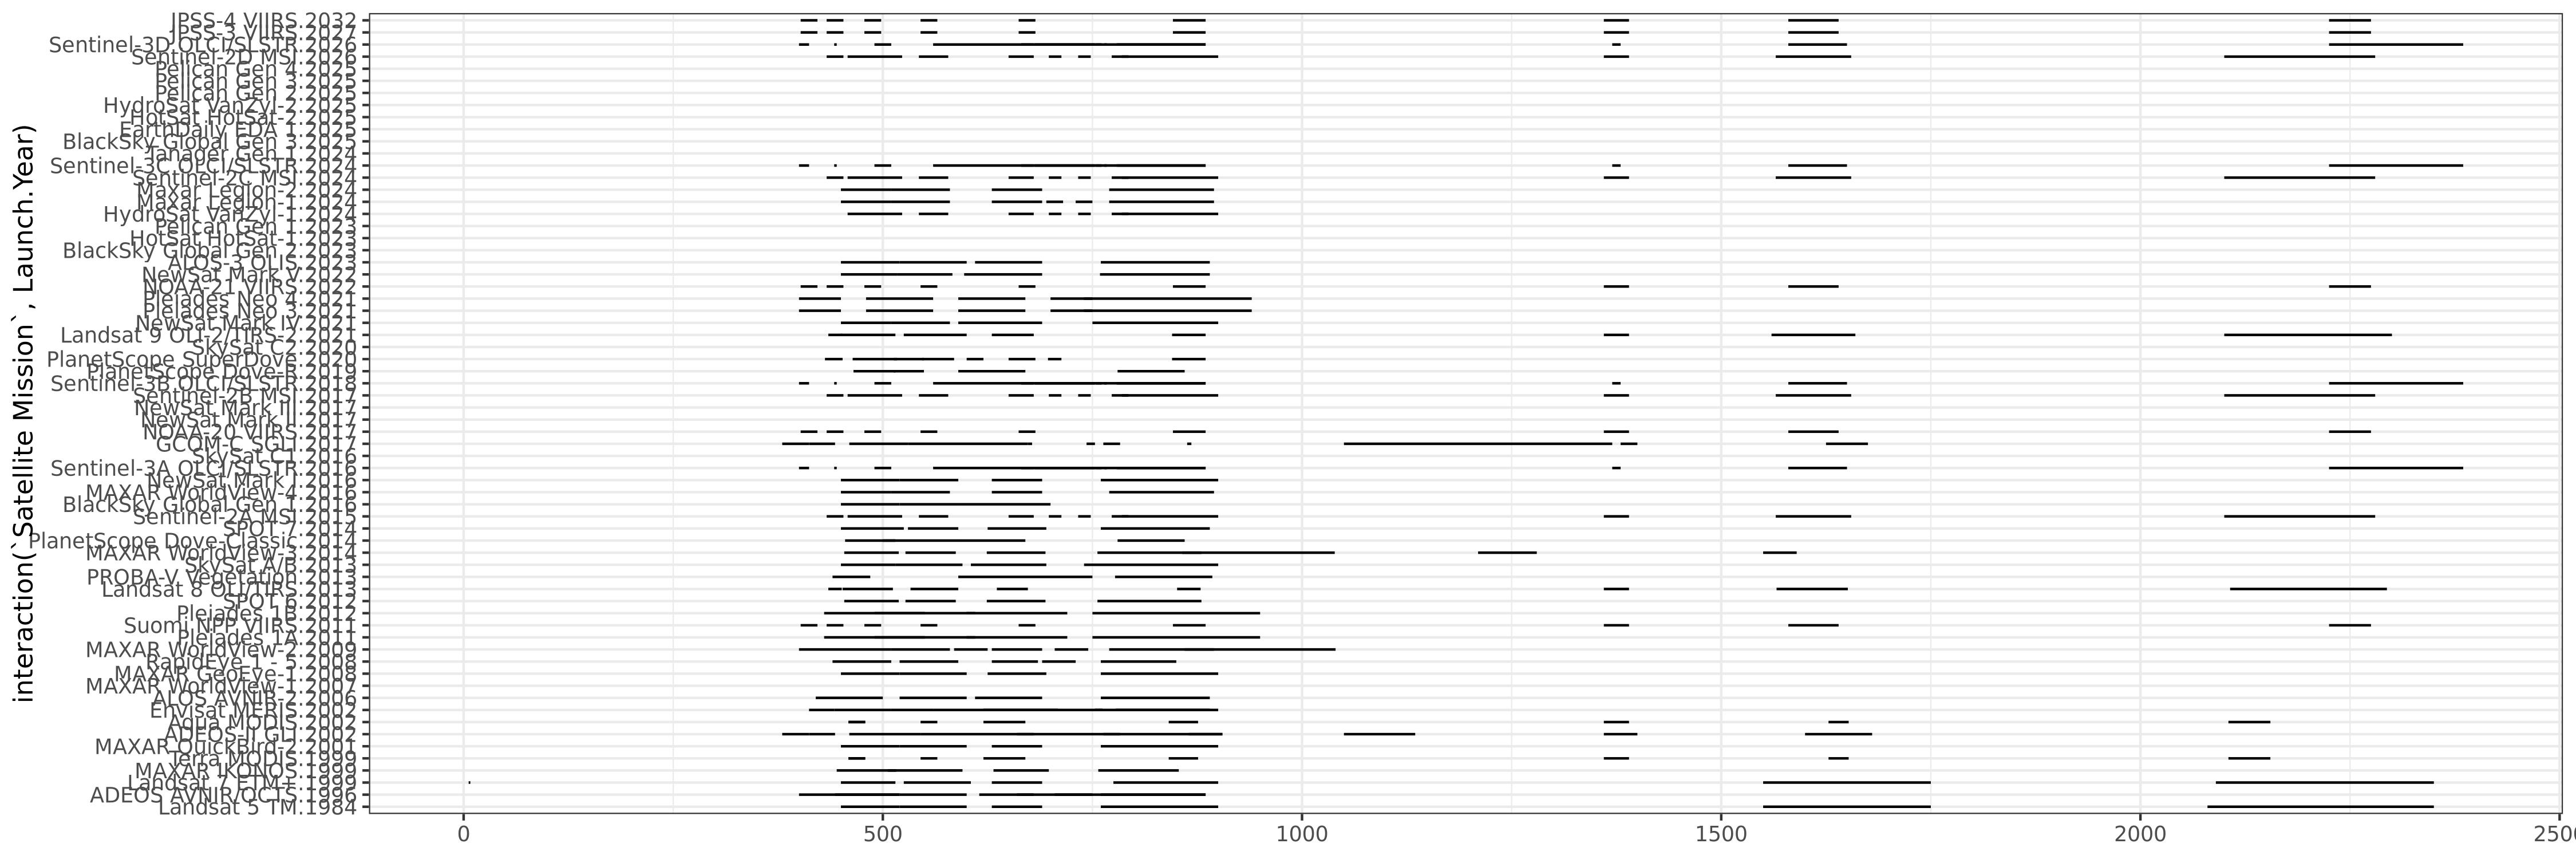

In [53]:
options(repr.plot.width =15, repr.plot.height = 5, repr.plot.res = 300)

ggplot(df_m_final_clean %>% filter(band != 'Pan')) +
    geom_linerange(aes(xmin=value_min, xmax=value_max, y=interaction(`Satellite Mission`,Launch.Year), group=`Affiliation`)) +
    #facet_wrap(~Parent.Company, scales='free_y', ncol=1) +
    theme_bw()

In [54]:
levels(df_m_final_clean$band)

[1] "Blue"       "Blue2"      "Coastal"    "Green1"     "Green2"    
 [6] "NIR"        "NIR2"       "Pan"        "Red"        "RedEdge"   
[11] "RedEdge1"   "RedEdge2"   "SWIR1"      "SWIR2"      "SWIRCirrus"
[16] "Yellow"

In [55]:
# band_colors <- c(
#         "Pan" = 'grey',
#         "Coastal" = 'purple', 
#         "Blue" = "#0066CC",      # Blue color
#         "BlueII" = "#0066CC",      # Blue color
#         "GreenI" = "#00AA44",     # Green color  
#         "GreenII" = "#00AA44",     # Green color 
#         "Yellow" = 'gold',
#         "Red" = "red",       # Red color
#         "RedEdgeI" = "indianred",       # Red color
#         "NIR" = "#8B4513",       # Brown for Near-Infrared
#         "SWIR1" = "darkred" ,      # Orange for Short-Wave Infrared (if you have it)
#         "SWIR2" = "brown"       # Orange for Short-Wave Infrared (if you have it)
# )
# Logical ordering from shortest to longest wavelength
band_order <- c(
  'Pan',         # ~450-800 nm (panchromatic - broad spectrum)
  'Coastal',     # ~400-450 nm (coastal/aerosol)
  'Blue',        # ~450-495 nm
  'Blue2',       # ~450-515 nm (extended blue)
  'Green1',      # ~495-570 nm
  'Green2',      # ~510-580 nm (extended green)
  'Yellow',      # ~570-590 nm
  'Red',         # ~620-750 nm
  'RedEdge',     # ~698-713 nm
  'RedEdge1',    # ~698-713 nm
  'RedEdge2',    # ~733-748 nm
  'NIR',         # ~750-900 nm
  'NIR2',        # ~845-885 nm (extended NIR)
  'SWIR1',       # ~1550-1750 nm
  'SWIR2',       # ~2080-2350 nm
  'SWIRCirrus'   # ~1360-1390 nm (cirrus detection)
)

# Create named color vector
band_colors <- c(
  'Pan' = '#808080',          # Gray (panchromatic covers broad spectrum)
  'Coastal' = '#4B0082',      # Indigo (shorter than visible)
  'Blue' = '#0000FF',         # Pure blue
  'Blue2' = '#1E90FF',        # Dodger blue (lighter blue)
  'Green1' = '#00FF00',       # Pure green
  'Green2' = '#32CD32',       # Lime green (slightly different green)
  'Yellow' = '#fee08b',       # Pure yellow = '#FFFF00'
  'Red' = '#FF0000',          # Pure red
  'RedEdge' = '#FF4500',      # Orange red (red-edge transition)
  'RedEdge1' = '#FF6347',     # Tomato (first red edge)
  'RedEdge2' = '#DC143C',     # Crimson (second red edge)
  'NIR' = '#8B4513',          # Saddle brown (near-infrared)
  'NIR2' = '#A0522D',         # Sienna (extended NIR)
  'SWIR1' = '#654321',        # Dark brown (short-wave infrared)
  'SWIR2' = '#8B4513',        # Brown (longer SWIR)
  'SWIRCirrus' = '#D2691E'    # Peru (cirrus detection band)
)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message in geom_linerange(aes(ymin = value_min, ymax = value_max), width = 0.1, :
“Ignoring unknown parameters: `width`”
Warning message:
“Removed 181 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 508 rows containing missing values or values outside the scale range
(`geom_segment()`).”


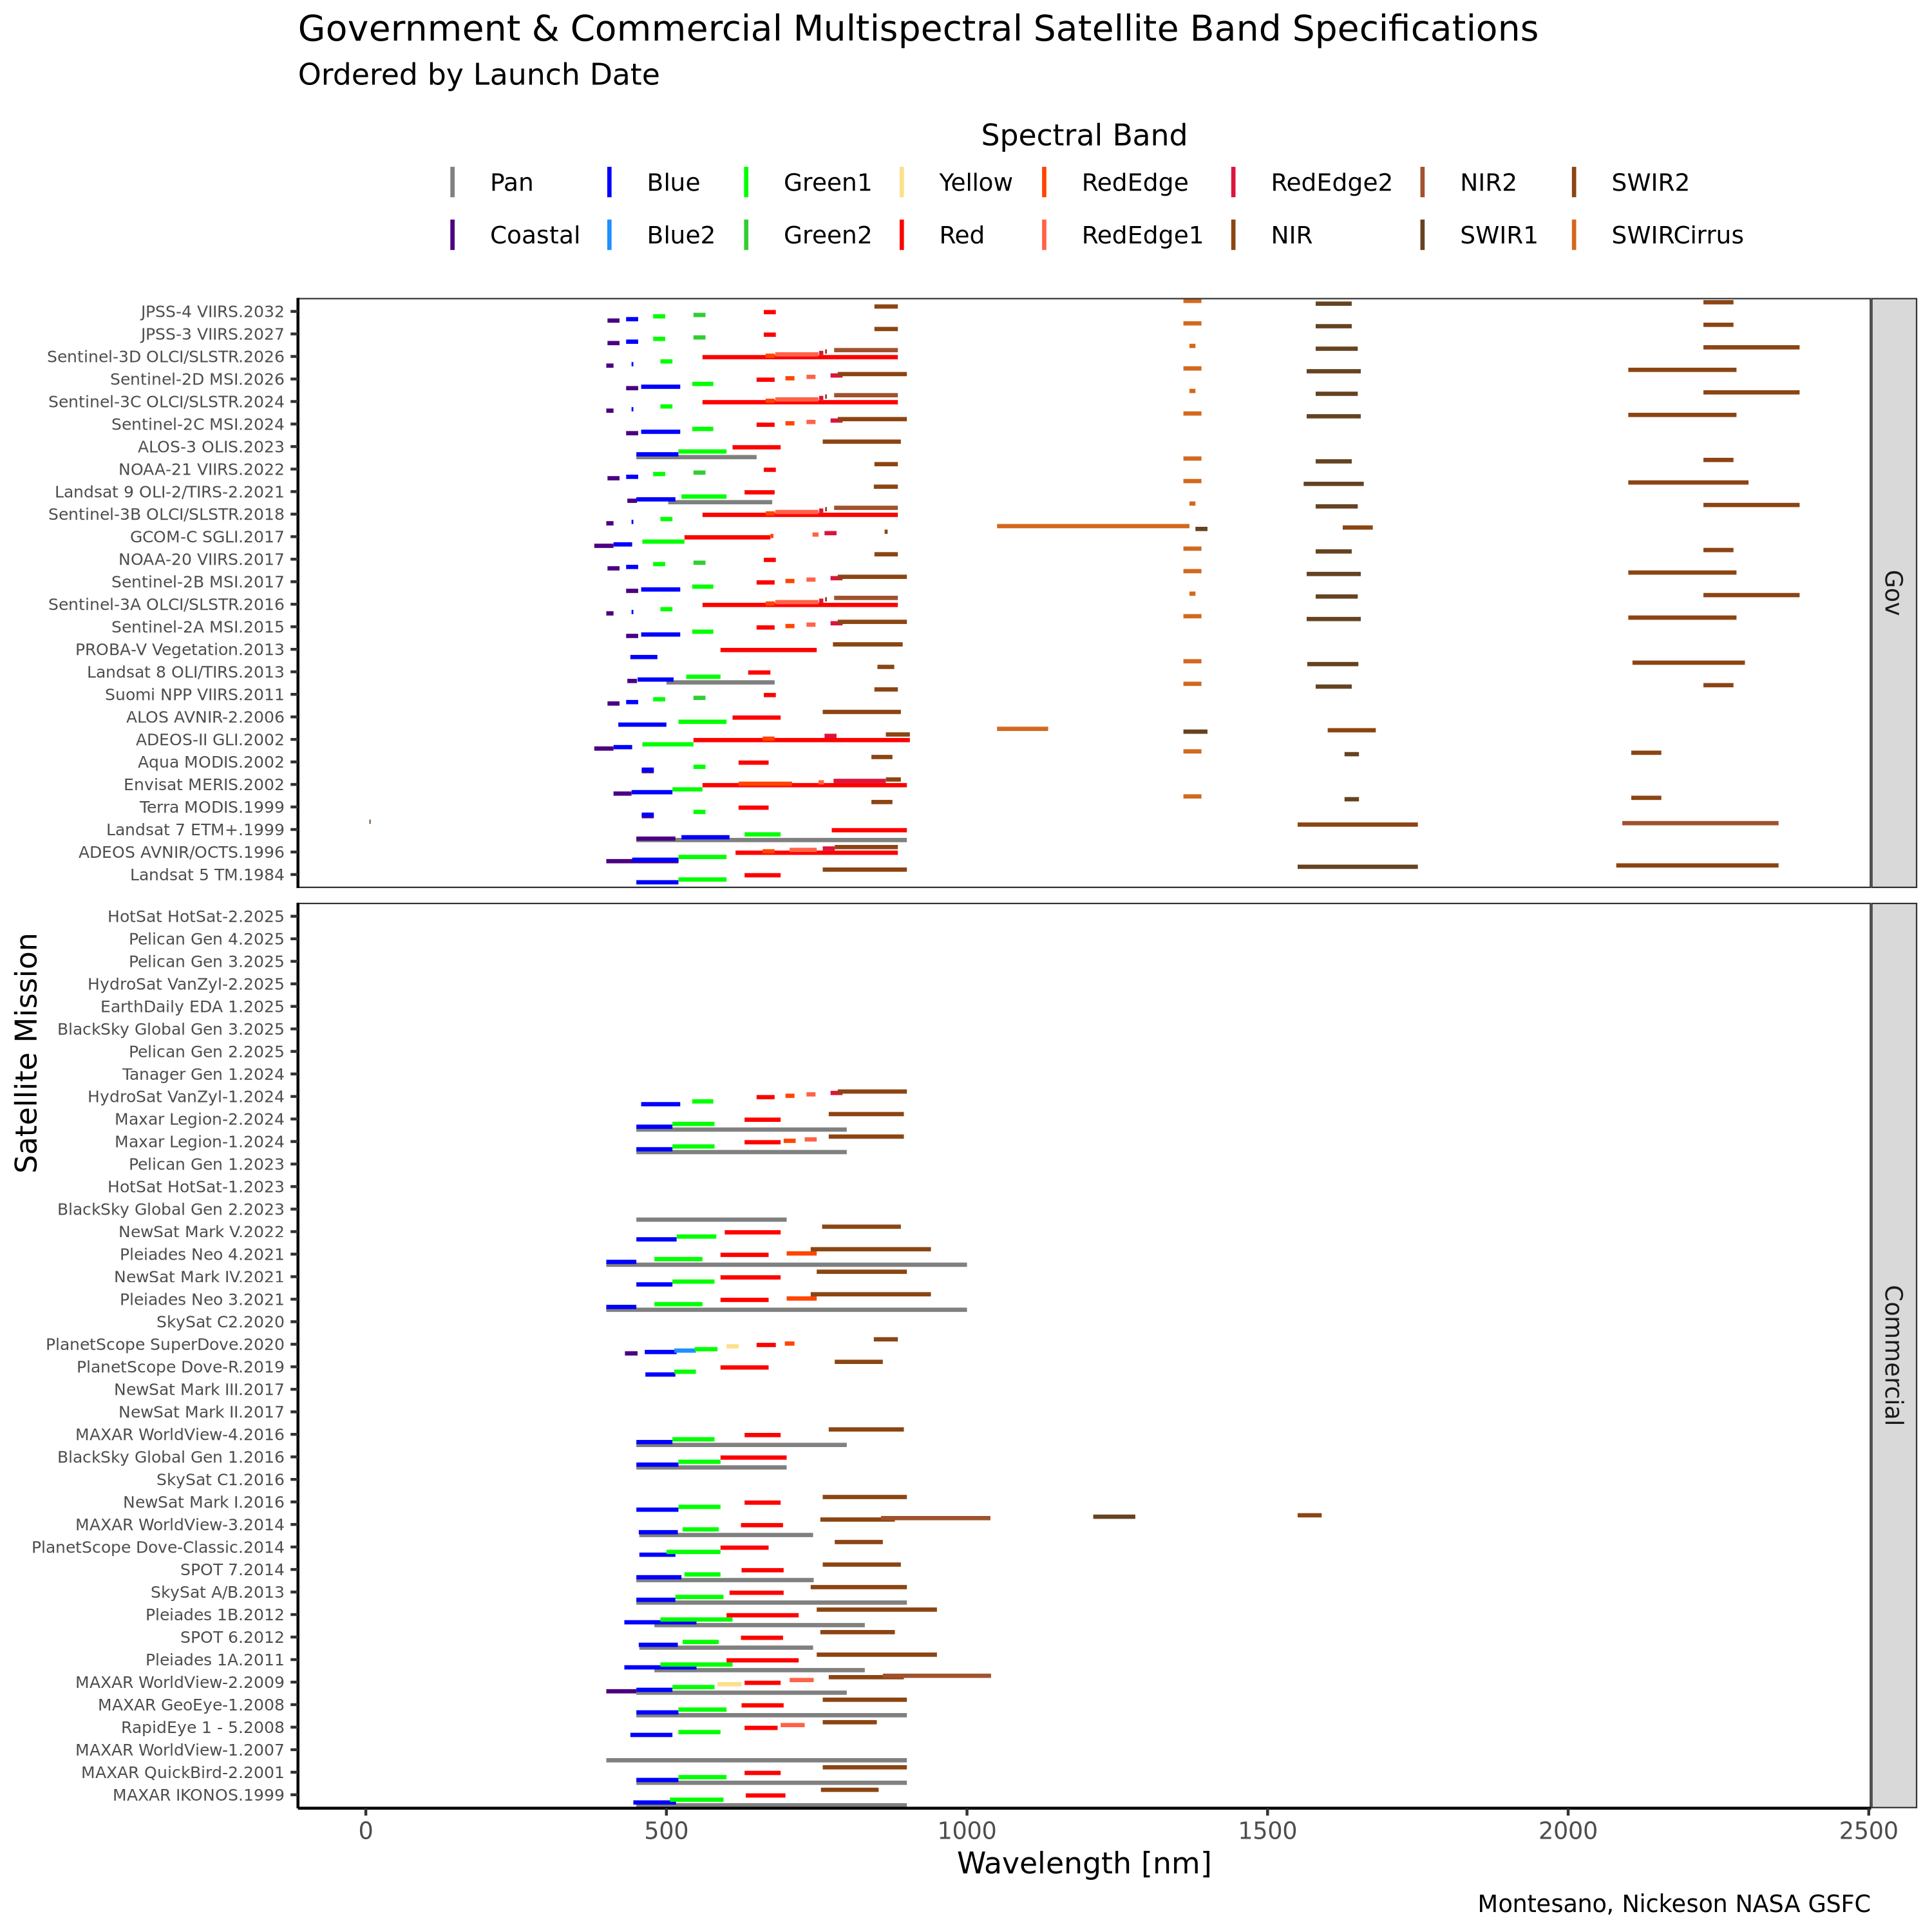

In [56]:
options(repr.plot.width =10, repr.plot.height = 10, repr.plot.res = 300)

#band_order <- c('Pan','Coastal','Blue','Blue2','Green1','Green2','Yellow','Red','RedEdge','RedEdge1','RedEdge2','NIR','NIR2','SWIR1','SWIR2','SWIRCirrus')

df_tmp = df_m_final_clean %>%
      mutate(Launch.Date = as.Date(Launch.Date)) %>%  # Adjust date function as needed
      arrange(Launch.Date) %>%
      mutate(`Satellite Mission` = factor(`Satellite Mission`, levels = unique(`Satellite Mission`))) %>%
      mutate(Sector = case_when(
        Sector == "Government" ~ "Gov",
        Sector == "Commercial" ~ "Commercial",
        TRUE ~ Sector
      )) %>%
    mutate(band = factor(band, levels = band_order)) %>%
    mutate(Sector = factor(Sector, levels = c("Gov","Commercial")))

p_spectral = ggplot(df_tmp
       , aes(x = interaction(`Satellite Mission`,Launch.Year), color = band
             #, group=Parent.Company
            )
      ) +
    geom_linerange(aes(ymin = value_min, ymax = value_max), 
            width = 0.1, size = 0.75
                   ,   position = position_dodge(width=1)
                  ) +
    scale_color_manual(values = band_colors) + 
    #geom_point(aes(y = (value_min + value_max) / 2), size = 3) +  # Midpoint
    #facet_wrap(~ `Affiliation`, ncol=1, scales='free_y') +
    labs(title = "Government & Commercial Multispectral Satellite Band Specifications",
       subtitle = "Ordered by Launch Date",
       x = "Satellite Mission",
       y = "Wavelength [nm]",
       color = "Spectral Band",
        caption = CAPTION_TEXT) +
    theme_bw() +
    #scale_y_log10() +
    coord_flip() + 
    theme(axis.text.x = element_text(angle = 0, hjust = 0.5), axis.text.y = element_text(angle = 0, hjust = 1, size=6), legend.position = "top") +
  # Remove default gridlines and background
  theme(
    panel.grid = element_blank(),
    panel.background = element_blank(),
    axis.line = element_line(color = "black")
  ) +
    guides(
        color = guide_legend(
          title.position = "top",
          title.hjust = 0.5,
          label.position = "right",
          ncol = 8,  # 2 columns
          nrow = 2,  # 6 rows
          byrow = FALSE,  # Fill by columns
          keywidth = unit(0.6, "cm"),
          keyheight = unit(0.5, "cm"),
          label.theme = element_text(size = 9),
          override.aes = list(
            shape = 1,
            size = 2.5,
            stroke = 0.4
          )
        )
        ) +
facet_grid(Sector ~ ., scales = "free", space = "free")
p_spectral

In [57]:
ggsave(filename = '/projects/my-private-bucket/databank/csda/vhr_spectral_bands.png',plot = p_spectral, width = 10, height = 9, dpi=300 )

Warning message:
“Removed 181 rows containing missing values or values outside the scale range
(`geom_segment()`).”
Warning message:
“Removed 508 rows containing missing values or values outside the scale range
(`geom_segment()`).”
